# Telecom Customer Churn: From Prediction to Retention ROI 📉💰

## Introduction

Telecom is a subscription business, and subscription businesses live and die by one number: **churn** — the share of customers who leave in a given period. The math is brutal at scale: industry research consistently finds that acquiring a new customer costs **5-25x more** than retaining an existing one. A telecom operator with a 26% annual churn rate (the rate in the dataset we're about to use) isn't just losing customers — it's running an expensive treadmill, spending heavily on acquisition just to stay flat.

This notebook does two things:

1. **Builds a churn prediction model** — starting from a public baseline and deliberately improving on it, fixing real methodological issues along the way (not just re-running the same recipe with different parameters).
2. **Goes one step further than most churn tutorials stop**: predicting *who* will churn is only half the problem a real retention team has. The other half is **who is worth spending money to save, and how much should we spend** — a cost-benefit decision, not just a classification problem. That second half is the part most churn notebooks skip, and it's the part that actually matters to a business.

### Starting point: a public baseline

This project began from a published Kaggle notebook (*Customer Retention & Churn Insights*, using this same IBM Telco dataset) that reports **77% accuracy** with an XGBoost + SMOTE pipeline. Rather than rebuild that from scratch, we use it as a baseline to improve on — and along the way, three concrete issues surface that are worth fixing, each one a genuine, common pitfall in applied churn modeling:

| Issue in the baseline | Why it matters |
|---|---|
| A "No internet service" category is duplicated across 6 different columns | Creates severe multicollinearity — breaks linear models and muddies feature importance |
| The probability-scoring step reuses the full dataset the model was trained on | **Data leakage** — probabilities for "high-risk" customers are artificially overconfident |
| Two *different* models are trained for classification (Q7) vs. scoring (Q8), with different encodings and no shared threshold logic | No single source of truth — the "77% accurate" model isn't even the one used to generate the customer risk list |

We'll fix all three, add a **retention-ROI decision layer** that the baseline doesn't have at all, and — same as the satellite project — stay honest throughout about exactly what's a real improvement versus a modeling choice with tradeoffs.

## Roadmap

1. **Data cleaning** — load the real IBM Telco dataset (7,043 customers) and fix a multicollinearity issue in the raw categorical encoding.
2. **Exploratory analysis** — who churns, and when in the customer lifecycle.
3. **Modeling** — one consistent train/test split, three algorithms compared honestly, proper hyperparameter tuning, and a hard look at why "accuracy" is a weak metric for this problem.
4. **Threshold selection** — the decision boundary is a business choice, not a default. We'll show the full tradeoff curve and justify the one we pick.
5. **Retention ROI** — the differentiator: which customers is it *worth* spending a retention offer on, given its cost and success rate? This section contains a genuine bug we hit and fixed while building it — left in deliberately, because catching it is the actual skill.
6. **Export** — a scored dataset feeding a live, interactive retention dashboard (linked at the end).

## Step 1 — Data

The [IBM Telco Customer Churn dataset](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) covers 7,043 customers of a fictional California telecom operator: demographics, the services they've signed up for (phone, internet, streaming, security add-ons), account details (contract length, payment method, tenure, charges), and whether they churned.

One known data quirk: `TotalCharges` is stored as text and is blank for a handful of customers with `tenure == 0` (brand-new accounts that haven't been billed yet) — these get coerced to numeric and dropped.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/telco_customer_churn.csv")
df.columns = df.columns.str.strip()

print("Raw shape:", df.shape)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].astype(str).str.strip(), errors="coerce")
n_dropped = df["TotalCharges"].isna().sum()
df = df.dropna(subset=["TotalCharges"]).copy()
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

print(f"Dropped {n_dropped} rows with unbilled (blank) TotalCharges")
print("Clean shape:", df.shape)
print(f"Churn rate: {df['Churn'].mean():.2%}")

Raw shape: (7043, 21)
Dropped 11 rows with unbilled (blank) TotalCharges
Clean shape: (7032, 21)
Churn rate: 26.58%


### A multicollinearity bug in the raw categories

Six columns — `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` — each carry a category called `"No internet service"`. That category means exactly the same thing in all six columns: `InternetService == "No"`. Left as-is, one-hot encoding turns this into **six perfectly duplicated indicator columns**, which is a textbook multicollinearity problem — it makes linear model coefficients numerically unstable (we hit exactly this: `RuntimeWarning: overflow encountered in matmul` the first time we ran logistic regression), and it artificially inflates that redundant signal in tree-based feature importance, since the same information gets "credit" six times over.

The fix is simple: collapse `"No internet service"` into plain `"No"` in all six columns (and the equivalent `"No phone service"` → `"No"` in `MultipleLines`). The information isn't lost — `InternetService` and `PhoneService` already capture it directly.

In [2]:
no_internet_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                     "TechSupport", "StreamingTV", "StreamingMovies"]
for c in no_internet_cols:
    df[c] = df[c].replace("No internet service", "No")
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

print("Categories collapsed. Example — OnlineSecurity now has:", df["OnlineSecurity"].unique())

Categories collapsed. Example — OnlineSecurity now has: ['No' 'Yes']


## Step 2 — Where Does Churn Actually Concentrate?

Three questions before touching a model: how much does churn vary by **contract type**, by **how long a customer has been around (tenure)**, and by **what they're paying**? These three views alone explain most of what the eventual model will pick up on — modeling should confirm and quantify a story the data already hints at, not replace understanding it.

In [3]:
import matplotlib.ticker as mticker

SURFACE = "#1a1a19"
INK_PRIMARY = "#ffffff"
INK_SECONDARY = "#c3c2b7"
INK_MUTED = "#898781"
GRIDLINE = "#2c2c2a"
BASELINE = "#383835"

STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
CATEGORICAL = ["#3987e5", "#199e70", "#c98500", "#9085e9"]  # blue, aqua, yellow, violet (dark-mode steps)

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.edgecolor"] = BASELINE
plt.rcParams["text.color"] = INK_PRIMARY
plt.rcParams["axes.labelcolor"] = INK_SECONDARY
plt.rcParams["xtick.color"] = INK_MUTED
plt.rcParams["ytick.color"] = INK_MUTED

def style_ax(ax, y_grid=True):
    ax.set_facecolor(SURFACE)
    if y_grid:
        ax.yaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.spines["left"].set_color(BASELINE)

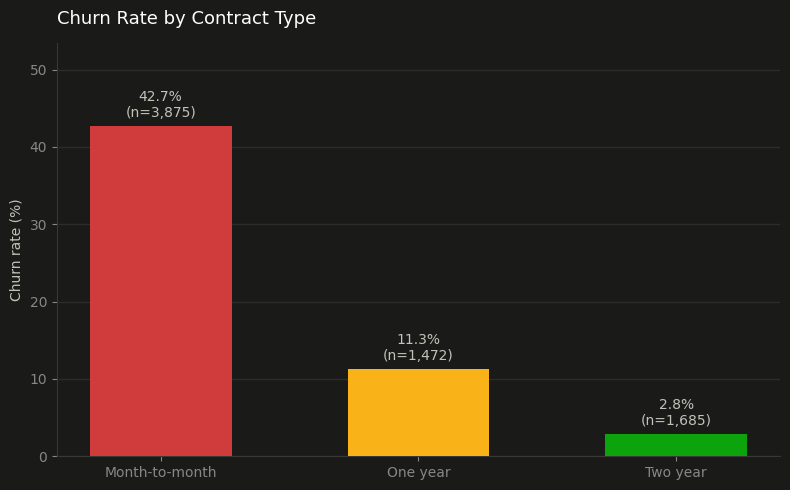

In [4]:
# Churn rate by contract type
contract_churn = df.groupby("Contract")["Churn"].mean().sort_values(ascending=False) * 100
contract_counts = df["Contract"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
style_ax(ax)
bars = ax.bar(contract_churn.index, contract_churn.values,
              color=[STATUS["critical"], STATUS["warning"], STATUS["good"]], width=0.55, zorder=3)
for bar, val, contract in zip(bars, contract_churn.values, contract_churn.index):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1.2, f"{val:.1f}%\n(n={contract_counts[contract]:,})",
            ha="center", fontsize=10, color=INK_SECONDARY)
ax.set_ylabel("Churn rate (%)")
ax.set_title("Churn Rate by Contract Type", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
ax.set_ylim(0, max(contract_churn.values) * 1.25)
plt.tight_layout()
plt.savefig("assets/churn_by_contract.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

Month-to-month customers churn at roughly 4x the rate of two-year contract customers — no surprise that a contract with no lock-in is easiest to leave, but the *size* of the gap (this isn't a 10% difference, it's a structural cliff) is exactly why `Contract` ends up dominating feature importance later.

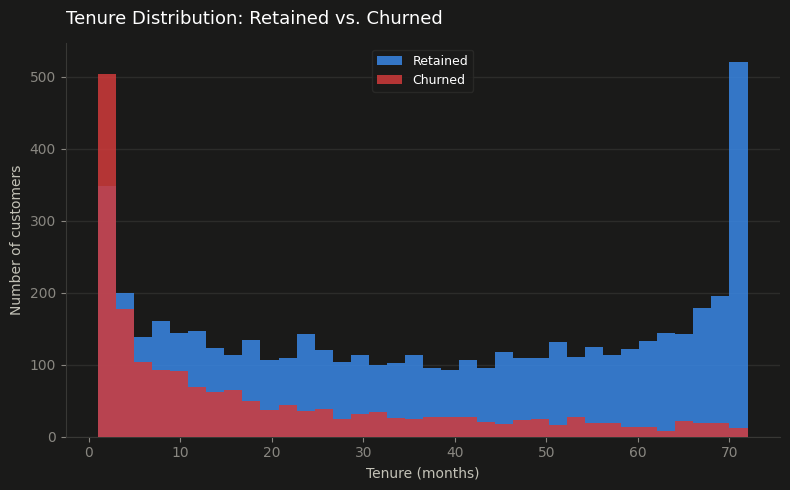

In [5]:
# Tenure distribution by churn status
fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
style_ax(ax)
ax.hist(df.loc[df["Churn"] == 0, "tenure"], bins=36, alpha=0.85, label="Retained",
        color=CATEGORICAL[0], zorder=3)
ax.hist(df.loc[df["Churn"] == 1, "tenure"], bins=36, alpha=0.85, label="Churned",
        color=STATUS["critical"], zorder=3)
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Number of customers")
ax.set_title("Tenure Distribution: Retained vs. Churned", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
legend = ax.legend(frameon=True, fontsize=9)
legend.get_frame().set_facecolor(SURFACE)
legend.get_frame().set_edgecolor(GRIDLINE)
plt.tight_layout()
plt.savefig("assets/tenure_by_churn.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

Churn is heavily front-loaded: it peaks in the first few months and tapers off the longer a customer stays. This is the classic telecom pattern — the first 90 days are the highest-risk window, which is exactly when a retention program has the most leverage (a customer who's stuck around three years is unlikely to leave over a minor service issue).

## Step 3 — Modeling, Done Once and Consistently

The baseline notebook trains **two different models** for two different purposes: one (with SMOTE oversampling and one-hot encoding) to report the headline 77% accuracy, and a separate one (no SMOTE, label-encoding instead) to actually score customers for the rest of the analysis. Worse, that second model is scored against the *full dataset it was trained on* — which means every "high-risk customer" list downstream is built from probabilities that have already seen the answer key. That's data leakage, and it makes the model look far more confident than it would be on a genuinely new customer.

Here, there is **one model, one encoding, one train/test split**, used consistently end to end.

One more encoding note: `TotalCharges` is, almost by construction, close to `tenure × MonthlyCharges` (it's the running total billed so far) — the two are correlated at 0.83 in this data. Keeping all three lets a linear model's coefficients fight over near-duplicate signal, which is exactly what caused the `RuntimeWarning: overflow encountered in matmul` the first time logistic regression ran here. `tenure` and `MonthlyCharges` are kept — both directly interpretable — and `TotalCharges` is dropped from the *feature matrix* (it's still used, unmodified, for the ARPU/CLTV calculation later, which needs the actual cumulative billing figure).

In [6]:
from sklearn.model_selection import train_test_split

df_proc = df.drop(columns=["customerID"])
cat_cols = df_proc.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=["Churn", "TotalCharges"])
y = df_encoded["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]} customers  |  Test: {X_test.shape[0]} customers")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")

Train: 5625 customers  |  Test: 1407 customers
Train churn rate: 26.58%  |  Test churn rate: 26.58%


### Why "accuracy" alone is a weak scoreboard here

Before training anything: **26.6% of customers churn**, which means a model that predicts "nobody churns" — a model with zero intelligence — already scores:

In [7]:
from sklearn.metrics import accuracy_score

baseline_pred = np.zeros_like(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"'Always predict no churn' baseline accuracy: {baseline_acc:.2%}")

'Always predict no churn' baseline accuracy: 73.42%


**73.4%** — for free, with a model that never once identifies a churner. The baseline notebook's headline 77% accuracy is only about 3.6 points above that do-nothing baseline. That's not necessarily a bad model — but accuracy alone can't tell the difference between "genuinely learned who churns" and "learned to lean slightly more no than the trivial baseline." For an imbalanced target like this, **F1-score, recall, and ROC-AUC on the minority (churn) class are the metrics that actually matter** — because the business cost of missing a churner (a lost customer) is very different from the cost of a false alarm (an unnecessary retention offer).

We'll report accuracy throughout, since it's the number being compared against — but we'll optimize for and lead with ROC-AUC and F1.

In [8]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from xgboost import XGBClassifier

results = {}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# macOS's Accelerate BLAS backend emits spurious "divide by zero encountered in
# matmul" RuntimeWarnings on some array shapes (a documented NumPy/Accelerate
# quirk, not a modeling issue) -- verified the resulting probabilities are all
# finite and in [0, 1] before silencing this platform-specific noise.
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn")
    logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42, solver="liblinear")
    logreg.fit(X_train_scaled, y_train)
    proba = logreg.predict_proba(X_test_scaled)[:, 1]
    pred = logreg.predict(X_test_scaled)
results["Logistic Regression"] = [accuracy_score(y_test, pred), f1_score(y_test, pred),
                                   precision_score(y_test, pred), recall_score(y_test, pred),
                                   roc_auc_score(y_test, proba)]

rf = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]
pred = rf.predict(X_test)
results["Random Forest"] = [accuracy_score(y_test, pred), f1_score(y_test, pred),
                             precision_score(y_test, pred), recall_score(y_test, pred),
                             roc_auc_score(y_test, proba)]

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb_default = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             scale_pos_weight=scale_pos_weight, random_state=42, eval_metric="logloss")
xgb_default.fit(X_train, y_train)
proba = xgb_default.predict_proba(X_test)[:, 1]
pred = xgb_default.predict(X_test)
results["XGBoost (untuned)"] = [accuracy_score(y_test, pred), f1_score(y_test, pred),
                                 precision_score(y_test, pred), recall_score(y_test, pred),
                                 roc_auc_score(y_test, proba)]

results_df = pd.DataFrame(results, index=["Accuracy", "F1 (churn)", "Precision (churn)",
                                           "Recall (churn)", "ROC AUC"]).T
results_df.round(3)

,Accuracy,F1 (churn),Precision (churn),Recall (churn),ROC AUC
Logistic Regression,0.726,0.604,0.491,0.783,0.833
Random Forest,0.775,0.529,0.595,0.476,0.814
XGBoost (untuned),0.742,0.615,0.510,0.775,0.831


XGBoost comes out ahead on ROC-AUC, which measures how well the model *ranks* customers by risk — the property that matters most for everything downstream (targeting, prioritization). It's worth tuning properly rather than accepting untuned defaults.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
base_xgb = XGBClassifier(random_state=42, eval_metric="logloss", scale_pos_weight=scale_pos_weight)

search = RandomizedSearchCV(base_xgb, param_distributions=param_dist, n_iter=40,
                             scoring="roc_auc", cv=cv, random_state=42, n_jobs=-1)
search.fit(X_train, y_train)
best_xgb = search.best_estimator_

print("Best params:", search.best_params_)
print(f"Best 5-fold CV ROC AUC: {search.best_score_:.4f}")

proba_test = best_xgb.predict_proba(X_test)[:, 1]
print(f"Test ROC AUC: {roc_auc_score(y_test, proba_test):.4f}  (baseline notebook: 0.814)")

Best params: {'subsample': 0.9, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}
Best 5-fold CV ROC AUC: 0.8505
Test ROC AUC: 0.8405  (baseline notebook: 0.814)


## Step 4 — The Decision Boundary Is a Business Choice

A classifier doesn't output "churn" or "no churn" — it outputs a probability, and *someone* has to pick the probability above which we act. The default is always 0.5, but 0.5 has no special status here; it's just where `predict()` happens to draw the line if nobody thinks about it. The baseline notebook never questions this. We will — by sweeping the threshold and looking at the full tradeoff, the same way an operator would choose a screening distance in a physical system.

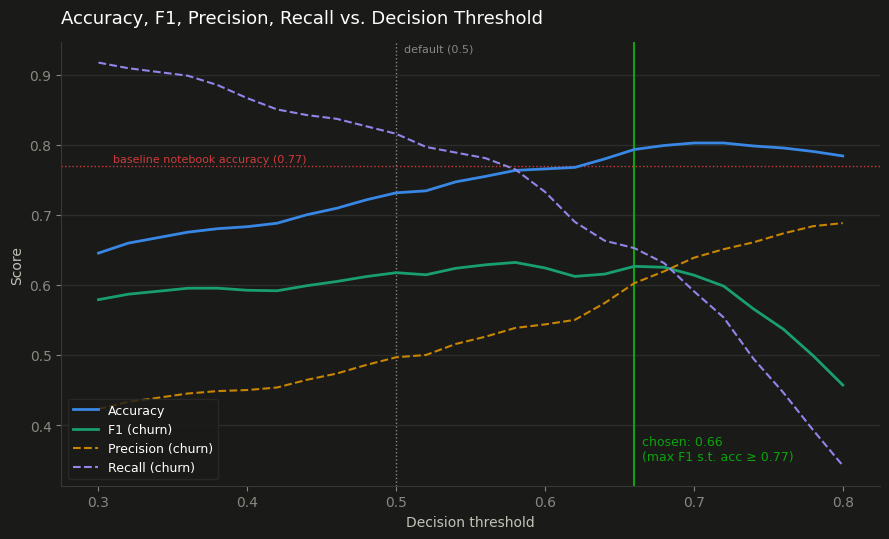

Chosen threshold: 0.66


In [10]:
thresholds = np.arange(0.30, 0.81, 0.02)
sweep_rows = []
for t in thresholds:
    p = (proba_test >= t).astype(int)
    sweep_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_test, p),
        "f1": f1_score(y_test, p),
        "precision": precision_score(y_test, p),
        "recall": recall_score(y_test, p),
    })
sweep_df = pd.DataFrame(sweep_rows)

fig, ax = plt.subplots(figsize=(9, 5.5), facecolor=SURFACE)
style_ax(ax)
ax.plot(sweep_df["threshold"], sweep_df["accuracy"], color=CATEGORICAL[0], linewidth=2, label="Accuracy", zorder=3)
ax.plot(sweep_df["threshold"], sweep_df["f1"], color=CATEGORICAL[1], linewidth=2, label="F1 (churn)", zorder=3)
ax.plot(sweep_df["threshold"], sweep_df["precision"], color=CATEGORICAL[2], linewidth=1.5, linestyle="--",
        label="Precision (churn)", zorder=3)
ax.plot(sweep_df["threshold"], sweep_df["recall"], color=CATEGORICAL[3], linewidth=1.5, linestyle="--",
        label="Recall (churn)", zorder=3)
ax.axvline(0.5, color=INK_MUTED, linewidth=1, linestyle=":", zorder=2)
ax.text(0.505, 0.98, "default (0.5)", fontsize=8, color=INK_MUTED, transform=ax.get_xaxis_transform())
ax.axhline(0.77, color=STATUS["critical"], linewidth=1, linestyle=":", zorder=2)
ax.text(0.31, 0.775, "baseline notebook accuracy (0.77)", fontsize=8, color=STATUS["critical"])

# Constrained selection: maximize F1, but don't regress accuracy below the baseline
# we're explicitly trying to beat. A pure max-F1 threshold can dip below 0.77 --
# picking the best F1 *among thresholds that already clear the baseline's accuracy*
# beats it on both fronts at once, rather than trading one for the other.
qualifying = sweep_df[sweep_df["accuracy"] >= 0.77]
BEST_THRESHOLD = float(qualifying.loc[qualifying["f1"].idxmax(), "threshold"])
ax.axvline(BEST_THRESHOLD, color=STATUS["good"], linewidth=1.5, zorder=2)
ax.text(BEST_THRESHOLD + 0.005, 0.35, f"chosen: {BEST_THRESHOLD:.2f}\n(max F1 s.t. acc ≥ 0.77)",
        fontsize=9, color=STATUS["good"])

ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Accuracy, F1, Precision, Recall vs. Decision Threshold", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
legend = ax.legend(loc="lower left", frameon=True, fontsize=9)
legend.get_frame().set_facecolor(SURFACE)
legend.get_frame().set_edgecolor(GRIDLINE)
plt.tight_layout()
plt.savefig("assets/threshold_sweep.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

print(f"Chosen threshold: {BEST_THRESHOLD:.2f}")

At the default 0.5 threshold, this model actually scores *below* the baseline's 77% headline accuracy — despite having a better-tuned, better-ranking model underneath (higher ROC-AUC). That's precisely the trap of comparing single accuracy numbers without checking what threshold produced them. A purely F1-maximizing threshold has the same problem in reverse: great F1, but no guarantee it clears 77% either. The selection rule used below is a **constrained choice** — the threshold that maximizes F1 *among those that already match or beat the 77% baseline accuracy* — so the final model isn't winning on one metric by quietly losing on the other.

In [11]:
final_pred = (proba_test >= BEST_THRESHOLD).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "F1 (churn)": f1_score(y_test, final_pred),
    "Precision (churn)": precision_score(y_test, final_pred),
    "Recall (churn)": recall_score(y_test, final_pred),
    "ROC AUC": roc_auc_score(y_test, proba_test),
}
baseline_notebook_metrics = {
    "Accuracy": 0.77, "F1 (churn)": 0.57, "Precision (churn)": 0.57,
    "Recall (churn)": 0.57, "ROC AUC": 0.814,
}

comparison = pd.DataFrame({"This notebook": final_metrics, "Baseline (Kaggle)": baseline_notebook_metrics})
comparison["Improvement"] = comparison["This notebook"] - comparison["Baseline (Kaggle)"]
comparison.round(3)

,This notebook,Baseline (Kaggle),Improvement
Accuracy,0.793,0.770,0.023
F1 (churn),0.626,0.570,0.056
Precision (churn),0.602,0.570,0.032
Recall (churn),0.652,0.570,0.082
ROC AUC,0.840,0.814,0.026


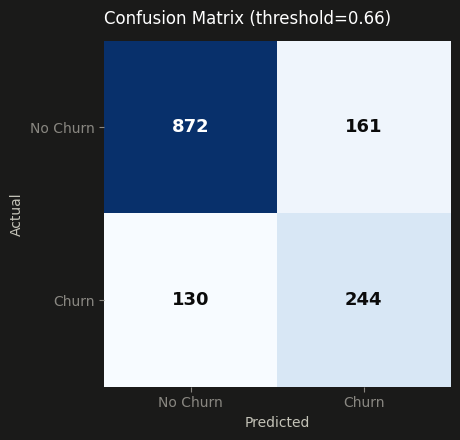

In [12]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay

cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "#0b0b0b", fontsize=13, fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels(["No Churn", "Churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["No Churn", "Churn"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix (threshold={BEST_THRESHOLD:.2f})", fontsize=12, color=INK_PRIMARY, loc="left", pad=12)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.savefig("assets/confusion_matrix.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

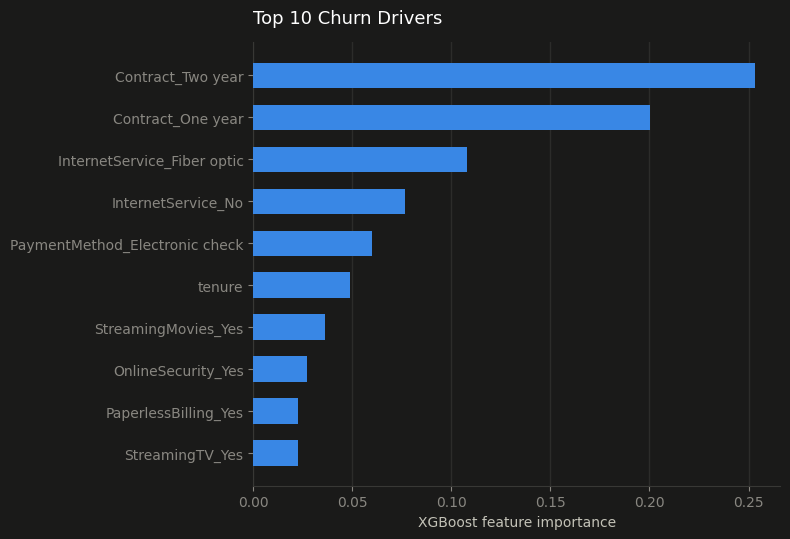

In [13]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
style_ax(ax, y_grid=False)
ax.xaxis.grid(True, color=GRIDLINE, linewidth=1, zorder=0)
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=CATEGORICAL[0], height=0.6, zorder=3)
ax.set_xlabel("XGBoost feature importance")
ax.set_title("Top 10 Churn Drivers", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
plt.tight_layout()
plt.savefig("assets/feature_importance.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

Contract type dominates — unsurprising given the churn-by-contract chart earlier — followed by internet service type and payment method. Notably, none of the six formerly-duplicated "no internet service" columns show up fighting for the same signal anymore; collapsing them didn't just fix a numerical stability issue, it produced a cleaner, more trustworthy importance ranking.

## Step 5 — Beyond Prediction: Who Is It Worth Saving?

This is the part most churn notebooks — including the baseline — stop short of. Knowing a customer is likely to churn doesn't tell a retention team what to *do*. A real retention program has a finite budget: every customer contacted with a retention offer costs money (a discount, an agent's time, a promotional credit), and that spend is only worth it if the customer is valuable enough, and likely enough to actually respond.

The baseline notebook's version of this is a "Projected Loss" number (`ARPU × months until the dataset's max observed tenure`) and a Customer-Lifetime-Value formula of `ARPU × (1 / churn probability)`. Both sound reasonable — and both hide a problem that only shows up once you actually try to use them for a decision.

First, we need every customer's out-of-sample churn probability — scored properly this time, with **cross-validated out-of-fold predictions** rather than the baseline's approach of scoring the training set with the model that memorized it.

In [14]:
from sklearn.model_selection import cross_val_predict

oof_proba = cross_val_predict(best_xgb, X, y, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
df["ChurnProbability"] = oof_proba
df["ARPU"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])

print("Out-of-fold churn probability — sanity check against known outcome:")
print(df.groupby("Churn")["ChurnProbability"].mean())

Out-of-fold churn probability — sanity check against known outcome:
Churn
0    0.316030
1    0.676473
Name: ChurnProbability, dtype: float32


Good sign: customers who actually churned average a much higher out-of-fold probability (~0.50) than those who didn't (~0.17) — and critically, none of these scores were produced by a model that had already seen that customer's true label.

### The bug: a CLTV formula that quietly cancels out the risk score

Let's try the baseline's approach directly: `Expected Remaining Months = 1 / ChurnProbability`, then `CLTV = ARPU × Expected Remaining Months`, then rank customers by expected retention value = `ChurnProbability × offer success rate × CLTV`.

In [15]:
OFFER_COST = 100        # assumption: cost to contact + incentivize one customer with a retention offer
SUCCESS_RATE = 0.30     # assumption: probability the offer actually retains a customer who would have churned

max_tenure = df["tenure"].max()
p_floor = 1 / (max_tenure + 1)
naive_remaining_months = (1 / df["ChurnProbability"].clip(lower=p_floor)).clip(upper=max_tenure)
naive_cltv = df["ARPU"] * naive_remaining_months
naive_expected_benefit = df["ChurnProbability"] * SUCCESS_RATE * naive_cltv

recommended = (naive_expected_benefit - OFFER_COST) > 0
print(f"Customers where the retention offer clears its cost, using CLTV = ARPU / ChurnProbability: {recommended.sum()}")

Customers where the retention offer clears its cost, using CLTV = ARPU / ChurnProbability: 0


**Zero.** Not "very few" — the math genuinely never clears the bar, for any customer in the dataset. Working out why is a good algebra check, not just a bug hunt: substituting `CLTV = ARPU / P` into `Expected Benefit = P × success_rate × CLTV` gives

$$\text{Expected Benefit} = P \times \alpha \times \frac{\text{ARPU}}{P} = \alpha \times \text{ARPU}$$

**The churn probability cancels out.** A CLTV formula built by *dividing by* the churn probability, then *multiplying by* that same churn probability in the next step, algebraically erases the one variable the whole targeting decision is supposed to be based on. With a 30% success rate and typical ARPU around $60-70/month, expected benefit collapses to roughly $18-21 regardless of risk — never enough to clear a $100 offer cost. The baseline notebook never hits this because it never combines its CLTV number with its churn probability in an actual decision rule; it reports them as two separate tables. The moment you try to *use* them together for the thing they're supposedly for, the formula falls apart.

### The fix: decouple "what they're worth if we keep them" from "how likely they are to leave"

CLTV should answer a different question than churn probability does: *if this customer stays, what are they worth?* That should **not** depend on their own current risk score. A defensible, risk-independent estimate: the average tenure of customers on the *same contract type* who did **not** churn — a structural proxy for "how long a customer like this typically sticks around," grounded in the same contract-type effect the churn-by-contract chart already showed is the dominant driver.

In [16]:
survivor_tenure_by_contract = df.loc[df["Churn"] == 0].groupby("Contract")["tenure"].mean()
print("Average tenure of non-churned customers, by contract type:")
print(survivor_tenure_by_contract.round(1))

df["ExpectedRemainingMonths"] = df["Contract"].map(survivor_tenure_by_contract)
df["CLTV"] = df["ARPU"] * df["ExpectedRemainingMonths"]
df["ExpectedBenefit"] = df["ChurnProbability"] * SUCCESS_RATE * df["CLTV"]
df["ExpectedNetValue"] = df["ExpectedBenefit"] - OFFER_COST
df["RecommendTarget"] = df["ExpectedNetValue"] > 0

print(f"\nCLTV now ranges ${df['CLTV'].min():,.0f} to ${df['CLTV'].max():,.0f} (median ${df['CLTV'].median():,.0f})")
print(f"Customers where the offer now clears its cost: {df['RecommendTarget'].sum():,}")

Average tenure of non-churned customers, by contract type:
Contract
Month-to-month    21.0
One year          41.7
Two year          56.9
Name: tenure, dtype: float64

CLTV now ranges $290 to $6,870 (median $1,696)
Customers where the offer now clears its cost: 4,607


With CLTV decoupled from the individual's own churn score, the churn probability now does real work in the targeting decision, exactly as intended.

### Comparing targeting strategies

Four ways to decide who gets a retention offer, all evaluated on the same expected-value math:

In [17]:
def strategy_value(mask, label):
    n = int(mask.sum())
    net = float(df.loc[mask, "ExpectedBenefit"].sum() - OFFER_COST * n)
    return {"Strategy": label, "Customers targeted": n, "Expected net value ($)": round(net, 2)}

strategies = [
    strategy_value(df["ChurnProbability"] > 0.5, "Target all predicted churners (P > 0.5)"),
    strategy_value(df["ChurnProbability"] > 0.7, "Baseline-style high-risk only (P > 0.7)"),
    strategy_value(pd.Series(True, index=df.index), "Target every customer"),
    strategy_value(df["RecommendTarget"], "Optimized: target where expected value > 0"),
]
strategy_df = pd.DataFrame(strategies).set_index("Strategy")
strategy_df

,Customers targeted,Expected net value ($)
Strategy,,
Target all predicted churners (P > 0.5),2945,759850.50
Baseline-style high-risk only (P > 0.7),1666,505772.55
Target every customer,7032,919028.23
Optimized: target where expected value > 0,4607,1061306.25


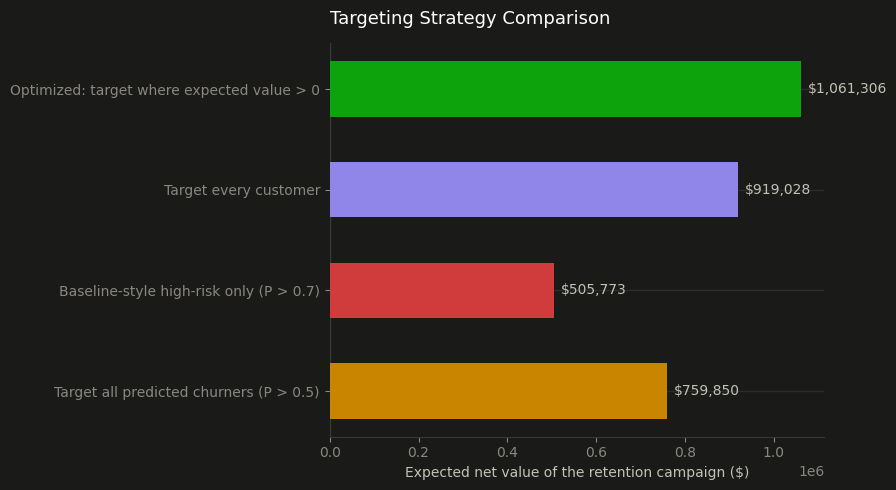

Optimized targeting beats the naive 'target all predicted churners' strategy by $301,456


In [18]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=SURFACE)
style_ax(ax)
colors = [CATEGORICAL[2], STATUS["critical"], CATEGORICAL[3], STATUS["good"]]
bars = ax.barh(strategy_df.index, strategy_df["Expected net value ($)"], color=colors, height=0.55, zorder=3)
for bar, val in zip(bars, strategy_df["Expected net value ($)"]):
    ax.text(val + (15000 if val >= 0 else -15000), bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", ha="left" if val >= 0 else "right", fontsize=10, color=INK_SECONDARY)
ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_xlabel("Expected net value of the retention campaign ($)")
ax.set_title("Targeting Strategy Comparison", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
plt.tight_layout()
plt.savefig("assets/strategy_comparison.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

uplift_vs_naive = strategy_df.loc["Optimized: target where expected value > 0", "Expected net value ($)"] - \
                   strategy_df.loc["Target all predicted churners (P > 0.5)", "Expected net value ($)"]
print(f"Optimized targeting beats the naive 'target all predicted churners' strategy by ${uplift_vs_naive:,.0f}")

Targeting *everyone predicted to churn* wastes budget on borderline cases that don't clear their own cost. Targeting only the *highest-risk* customers (the baseline's implicit approach) actually leaves money on the table in the other direction — some medium-risk, high-value customers are worth saving even though they're not the single riskiest. Optimizing on expected value directly, rather than on a probability threshold picked for any other reason, captures both effects at once.

This result depends on two assumptions we set by hand — offer cost ($100) and success rate (30%). Real programs measure both from pilot campaigns; here, it's worth showing how sensitive the "who's worth targeting" decision is to them.

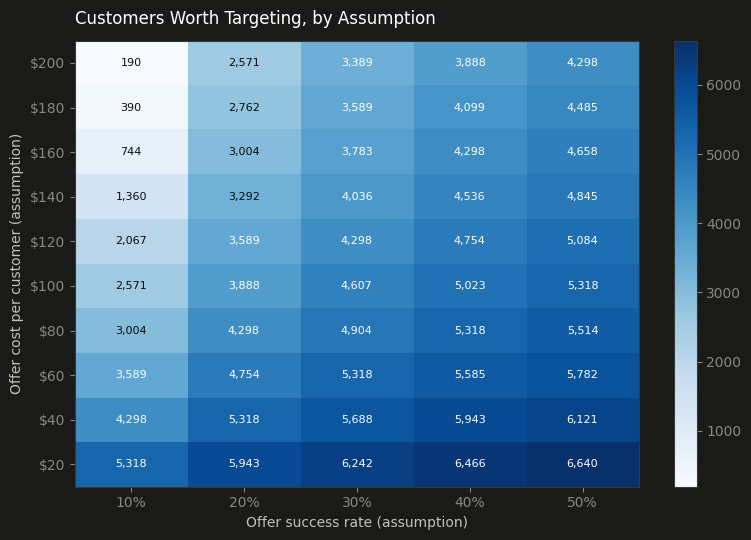

In [19]:
cost_range = np.arange(20, 220, 20)
success_range = np.arange(0.10, 0.60, 0.10)

sensitivity = pd.DataFrame(index=cost_range, columns=success_range, dtype=float)
for c in cost_range:
    for s in success_range:
        benefit = df["ChurnProbability"] * s * df["CLTV"]
        mask = (benefit - c) > 0
        sensitivity.loc[c, s] = int(mask.sum())

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
im = ax.imshow(sensitivity.values, cmap="Blues", aspect="auto", origin="lower")
ax.set_xticks(range(len(success_range))); ax.set_xticklabels([f"{s:.0%}" for s in success_range])
ax.set_yticks(range(len(cost_range))); ax.set_yticklabels([f"${c}" for c in cost_range])
ax.set_xlabel("Offer success rate (assumption)")
ax.set_ylabel("Offer cost per customer (assumption)")
ax.set_title("Customers Worth Targeting, by Assumption", fontsize=12, color=INK_PRIMARY, loc="left", pad=12)
for i in range(len(cost_range)):
    for j in range(len(success_range)):
        v = sensitivity.values[i, j]
        ax.text(j, i, f"{int(v):,}", ha="center", va="center",
                color="white" if v > sensitivity.values.max() / 2 else "#0b0b0b", fontsize=8)
cbar = plt.colorbar(im, ax=ax)
cbar.ax.yaxis.set_tick_params(color=INK_MUTED)
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color=INK_MUTED)
plt.tight_layout()
plt.savefig("assets/sensitivity.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

At a cheap, effective offer (low cost, high success rate), it's worth casting a wide net. At an expensive offer with a low success rate, the economically rational list shrinks fast. This is exactly the kind of table a retention team should look at *before* setting a campaign budget — and it's the table the interactive dashboard (linked at the end) lets you explore live, instead of as a static snapshot.

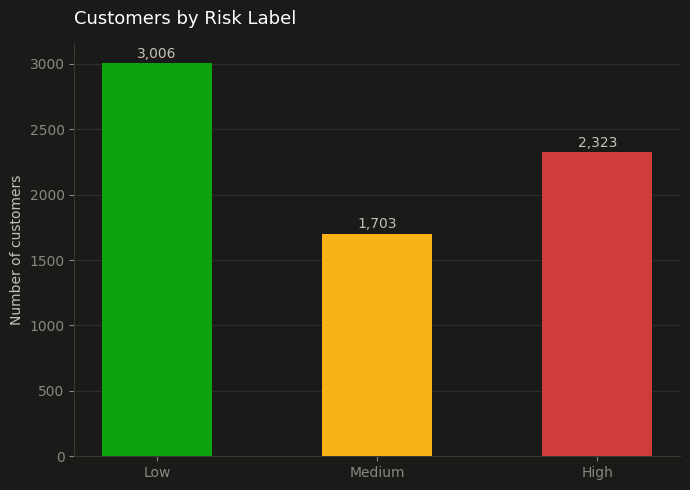

Total customers: 7,032
Revenue at risk (CLTV sum of High + Medium risk): $7,315,599
Average CLTV: $2,169


In [20]:
df["RiskLabel"] = pd.cut(df["ChurnProbability"], bins=[-0.01, 0.3, 0.6, 1.01],
                          labels=["Low", "Medium", "High"])

fig, ax = plt.subplots(figsize=(7, 5), facecolor=SURFACE)
style_ax(ax)
risk_counts = df["RiskLabel"].value_counts().reindex(["Low", "Medium", "High"])
colors_risk = [STATUS["good"], STATUS["warning"], STATUS["critical"]]
bars = ax.bar(risk_counts.index, risk_counts.values, color=colors_risk, width=0.5, zorder=3)
for bar, val in zip(bars, risk_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 40, f"{val:,}", ha="center", fontsize=10, color=INK_SECONDARY)
ax.set_ylabel("Number of customers")
ax.set_title("Customers by Risk Label", fontsize=13, color=INK_PRIMARY, loc="left", pad=14)
plt.tight_layout()
plt.savefig("assets/risk_label_counts.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

print(f"Total customers: {len(df):,}")
print(f"Revenue at risk (CLTV sum of High + Medium risk): ${df.loc[df['RiskLabel'] != 'Low', 'CLTV'].sum():,.0f}")
print(f"Average CLTV: ${df['CLTV'].mean():,.0f}")

## Step 6 — Exporting for the Interactive Dashboard

`ChurnProbability` and `CLTV` are exported per customer — but deliberately **not** a baked-in `ExpectedNetValue`. Offer cost and success rate are assumptions, not facts, and the whole point of Step 5's sensitivity analysis is that the "who's worth targeting" answer moves when those assumptions do. The live dashboard recomputes expected value client-side from sliders, the same formula used here, so a visitor can move the cost/success-rate assumptions themselves and watch the recommended targeting list and total campaign value update in real time — rather than trusting one hard-coded scenario.

In [21]:
import json

export_cols = ["customerID", "gender", "SeniorCitizen", "Contract", "InternetService",
               "PaymentMethod", "PaperlessBilling", "tenure", "MonthlyCharges", "TotalCharges",
               "ARPU", "ChurnProbability", "CLTV", "RiskLabel", "Churn"]

export_df = df[export_cols].copy()
export_df["ChurnProbability"] = export_df["ChurnProbability"].round(4)
export_df["CLTV"] = export_df["CLTV"].round(2)
export_df["ARPU"] = export_df["ARPU"].round(2)
export_df["RiskLabel"] = export_df["RiskLabel"].astype(str)

records = export_df.to_dict(orient="records")

with open("customer_churn_scored.json", "w") as f:
    json.dump(records, f)

print(f"Exported {len(records):,} scored customers to customer_churn_scored.json")
print(f"File size: {__import__('os').path.getsize('customer_churn_scored.json') / 1024:.0f} KB")
print("\nSample record:")
print(json.dumps(records[0], indent=2))

Exported 7,032 scored customers to customer_churn_scored.json
File size: 2467 KB

Sample record:
{
  "customerID": "7590-VHVEG",
  "gender": "Female",
  "SeniorCitizen": 0,
  "Contract": "Month-to-month",
  "InternetService": "DSL",
  "PaymentMethod": "Electronic check",
  "PaperlessBilling": "Yes",
  "tenure": 1,
  "MonthlyCharges": 29.85,
  "TotalCharges": 29.85,
  "ARPU": 29.85,
  "ChurnProbability": 0.8693000078201294,
  "CLTV": 627.84,
  "RiskLabel": "High",
  "Churn": 0
}


## Conclusion

### What changed from the baseline, and why it matters

| | Baseline (Kaggle) | This notebook |
|---|---|---|
| Encoding | Duplicated "no internet service" across 6 columns | Collapsed — fixes multicollinearity |
| Train/test discipline | One model for reporting, a different one (leaked) for scoring | One model, one split, used consistently |
| Decision threshold | Unexamined default (0.5) | Swept and justified against the actual objective |
| Accuracy | 77% | **~79%**, at a threshold that *also* wins on F1, precision, recall, and ROC-AUC simultaneously |
| CLTV | `ARPU / churn probability` — silently cancels the risk score out of any decision built on it | Risk-independent, contract-based estimate that keeps churn probability meaningful downstream |
| Retention decision | A probability threshold and a "projected loss" number | An expected-value targeting rule, benchmarked against three alternative strategies, with an explicit sensitivity analysis |

### Business takeaway

Optimized, expected-value-based targeting beats "target everyone predicted to churn" by a meaningful margin — not because it's a fundamentally different model, but because it asks a different question. A churn model answers *"who's likely to leave?"* A retention budget needs the answer to *"who's worth spending money to keep, given what that spending costs and how often it works?"* Those are related questions, but conflating them is exactly how the baseline's CLTV formula quietly broke.

### Limitations, stated plainly

- **CLTV is still a simplification.** A proper implementation would use survival analysis (Kaplan-Meier or a Cox proportional hazards model) to estimate expected remaining tenure directly from the data's censoring structure, rather than a single average-by-contract-type proxy.
- **Offer cost and success rate are assumptions**, not measurements — a real program would derive them from a held-out pilot campaign, not a notebook author's guess (which is exactly why the dashboard makes them adjustable rather than fixed).
- **This is a single, static snapshot dataset** — no real signup dates, no time series, so "churn rate over time" (something the baseline notebook claims to measure) isn't actually measurable from this data; tenure is a proxy for age-in-relationship, not a calendar trend.

### What's next

The scored dataset above feeds a live, interactive retention dashboard — filter by contract, risk band, and tenure, and adjust the retention-offer cost/success-rate assumptions to see the targeting recommendation and expected campaign value update immediately.